# 06 — Tuning de Hiperparâmetros

**Objetivo:** Otimizar os hiperparâmetros do melhor modelo de cada grupo para maximizar
a área sob a curva Precisão-Recall (`average_precision_score`), métrica diretamente
alinhada com a meta de negócio: **Recall ≥ 0.70 e Precisão ≥ 0.60**.

**Método:** `RandomizedSearchCV` com `StratifiedKFold(n_splits=5)`, executado apenas sobre
o split de treino. Threshold final otimizado no val com o modelo tunado.

---

| Entrada | Descrição |
|---|---|
| `data/processed/splits/{grupo}/train.parquet` | Split de treino |
| `data/processed/splits/{grupo}/val.parquet` | Split de validação |
| `data/processed/splits/{grupo}/test.parquet` | Split de teste |
| `data/processed/feature_selection/{grupo}/selected_features.json` | Features selecionadas |
| `models/{grupo}/model_metadata.json` | Tipo de modelo eleito no 05 |

| Saída | Descrição |
|---|---|
| `models/{grupo}/best_model_tuned.joblib` | Modelo tunado |
| `models/{grupo}/tuning_metadata.json` | Melhores parâmetros, AUC-PR, threshold, Recall, Precisão |

## 1 · Setup & Configuração

In [5]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from pathlib import Path
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, f1_score,
    recall_score, precision_score,
)
from xgboost import XGBClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')

# Limitar uso de CPU/memória

os.environ["OMP_NUM_THREADS"]      = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"]      = "2"

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")

pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-04-13 17:40


In [6]:
# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd().parent
DATA_SPLITS  = PROJECT_ROOT / "data" / "processed" / "splits"
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection"
MODELS_DIR   = PROJECT_ROOT / "models"

GRUPOS   = ["Vendas", "Transporte", "Fábrica"]
RNG_SEED = 42

# ── Meta de negócio ───────────────────────────────────────────
META_RECALL    = 0.70   # recall mínimo exigido
META_PRECISION = 0.60   # precisão mínima exigida

# ── Parâmetros do RandomizedSearchCV ─────────────────────────
N_ITER_SEARCH = 25    # número de combinações testadas por grupo
CV_FOLDS      = 3     # folds de validação cruzada (StratifiedKFold)
N_JOBS        = 2     # paralelismo limitado para não sobrecarregar a máquina

# ── Grids de hiperparâmetros por tipo de modelo ───────────────
PARAM_GRIDS = {
    "RandomForest": {
        "n_estimators"     : [100, 200, 300],
        "max_depth"        : [4, 6, 8, None],
        "min_samples_leaf" : [2, 5, 8, 12],
        "min_samples_split": [2, 5, 10],
        "max_features"     : ["sqrt", "log2", 0.4],
        "class_weight"     : ["balanced", "balanced_subsample"],
    },
    "XGBoost": {
        "n_estimators" : [100, 200, 300],
        "max_depth"    : [3, 4, 5],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample"    : [0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_alpha"    : [0, 0.1, 0.5],
        "reg_lambda"   : [1.0, 2.0, 5.0],
        "min_child_weight": [1, 3, 5],
    },
    "LightGBM": {
        "n_estimators"    : [100, 200, 300],
        "num_leaves"      : [15, 31, 63],
        "max_depth"       : [3, 4, 6, -1],
        "learning_rate"   : [0.03, 0.05, 0.1],
        "subsample"       : [0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_alpha"       : [0, 0.1, 0.5],
        "min_child_samples": [10, 20, 40],
    },
    "LogisticRegression": {
        "C"       : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        "penalty" : ["l2"],
        "solver"  : ["lbfgs", "saga"],
        "max_iter": [500, 1000],
    },
}

print(f"Grupos   : {GRUPOS}")
print(f"Meta     : Recall >= {META_RECALL}  |  Precisão >= {META_PRECISION}")
print(f"CV folds : {CV_FOLDS}  |  Iterações : {N_ITER_SEARCH}")
print(f"Execução : {datetime.now():%Y-%m-%d %H:%M}")

Grupos   : ['Vendas', 'Transporte', 'Fábrica']
Meta     : Recall >= 0.7  |  Precisão >= 0.6
CV folds : 3  |  Iterações : 25
Execução : 2026-04-13 17:40


## 2 · Tuning por Grupo


GRUPO: Vendas
  Modelo base (LightGBM)  |  22 features
  Treino : 9,843 × 22  |  turnover: 37.81%
  Modelo 05  → AP-val=0.6546  @rec>=0.7: prec=0.5237  rec=0.8184 [fallback: Pre>=0.50]
  Rodando RandomizedSearchCV (25 iterações × 3 folds)...
  Melhor AP-CV = 0.7917
  Melhores parâmetros: {'subsample': 1.0, 'reg_alpha': 0.5, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
  Modelo tunado → AP-val=0.6248 (ganho=-0.0299)  AP-test=0.7439
  @rec>=0.7 no val : prec=0.5105  rec=0.8195  → abaixo da meta [fallback: Pre>=0.50]
  Val  → recall=0.8195  prec=0.5105  f1=0.6291
  Test → recall=0.8561  prec=0.5138  f1=0.6421


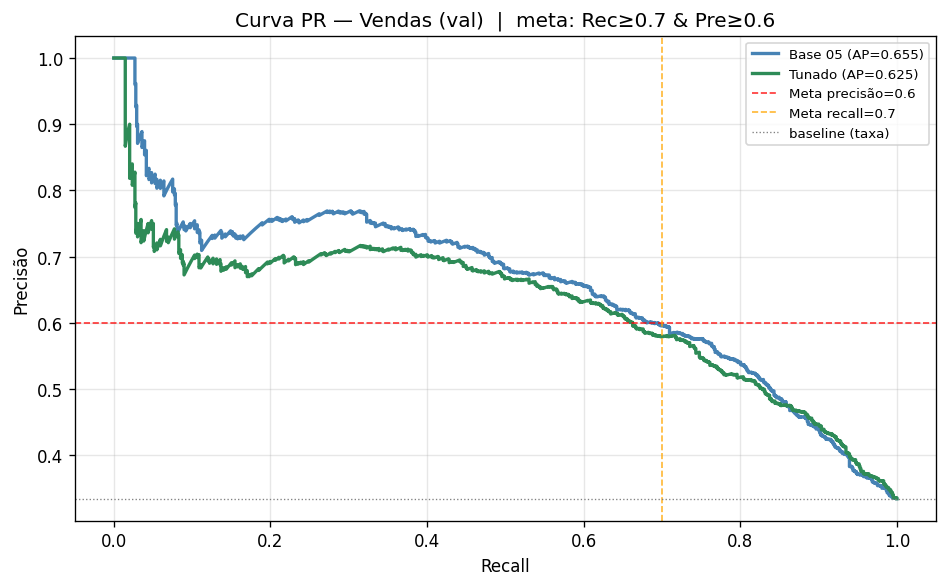

  ✓ best_model_tuned.joblib  +  tuning_metadata.json

GRUPO: Transporte
  Modelo base (LightGBM)  |  50 features
  Treino : 13,637 × 50  |  turnover: 39.36%
  Modelo 05  → AP-val=0.5387  @rec>=0.7: prec=0.4082  rec=0.8909 [fallback: Rec>=0.70 apenas]
  Rodando RandomizedSearchCV (25 iterações × 3 folds)...
  Melhor AP-CV = 0.8157
  Melhores parâmetros: {'subsample': 1.0, 'reg_alpha': 0.5, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
  Modelo tunado → AP-val=0.5154 (ganho=-0.0233)  AP-test=0.7615
  @rec>=0.7 no val : prec=0.4253  rec=0.8468  → abaixo da meta [fallback: Rec>=0.70 apenas]
  Val  → recall=0.8468  prec=0.4253  f1=0.5663
  Test → recall=0.8780  prec=0.5180  f1=0.6516


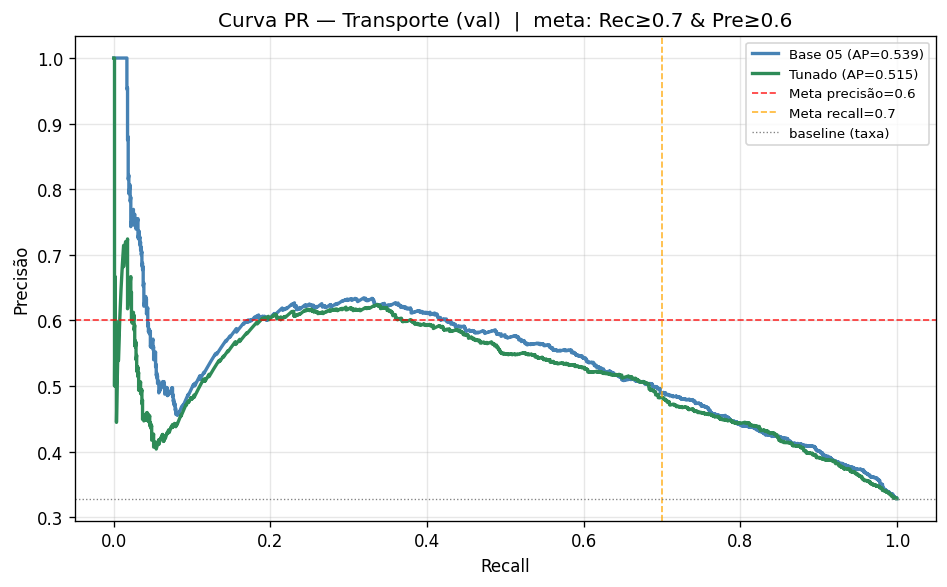

  ✓ best_model_tuned.joblib  +  tuning_metadata.json

GRUPO: Fábrica
  Modelo base (LightGBM)  |  54 features
  Treino : 5,723 × 54  |  turnover: 39.28%
  Modelo 05  → AP-val=0.6964  @rec>=0.7: prec=0.5271  rec=0.8261 [fallback: Pre>=0.50]
  Rodando RandomizedSearchCV (25 iterações × 3 folds)...
  Melhor AP-CV = 0.7798
  Melhores parâmetros: {'subsample': 0.8, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Modelo tunado → AP-val=0.6991 (ganho=+0.0026)  AP-test=0.7107
  @rec>=0.7 no val : prec=0.6095  rec=0.7051  → META ATINGIDA
  Val  → recall=0.7051  prec=0.6095  f1=0.6538
  Test → recall=0.7751  prec=0.5658  f1=0.6541


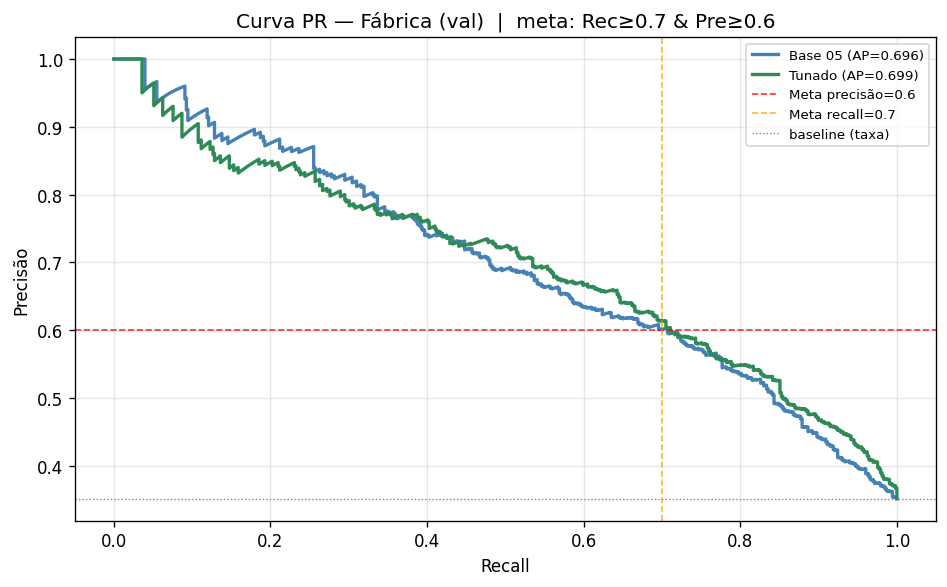

  ✓ best_model_tuned.joblib  +  tuning_metadata.json

✓ Tuning concluído para 3 grupos


In [7]:
# ── Funções auxiliares ────────────────────────────────────────
def _build_base_model(model_name: str, spw: float, seed: int):
    """Instancia o modelo base (sem hiperparâmetros) para o search."""
    if model_name == "RandomForest":
        return RandomForestClassifier(random_state=seed, n_jobs=N_JOBS)
    if model_name == "XGBoost":
        return XGBClassifier(
            scale_pos_weight=spw, random_state=seed,
            eval_metric="logloss", verbosity=0, n_jobs=N_JOBS,
        )
    if model_name == "LightGBM":
        return lgb.LGBMClassifier(
            scale_pos_weight=spw, random_state=seed,
            verbose=-1, n_jobs=N_JOBS,
        )
    if model_name == "LogisticRegression":
        return LogisticRegression(class_weight="balanced", random_state=seed)
    raise ValueError(f"Modelo desconhecido: {model_name}")


def _best_threshold(y_true, proba, meta_recall, meta_prec):
    """Varredura em grid de 0.005; score = F-beta com beta2=2.5.
    Regra invariante: recall >= precision (foco em recall sempre).
    Uma vez recall>=meta atingido, otimiza F-beta priorizando recall (beta2=2.5).
    Se meta de recall não for atingível, retorna o maior recall disponível ('quase')."""
    BETA2 = 2.5
    grid_th = np.arange(0.005, 1.0, 0.005)
    rows = []
    for th in grid_th:
        pred_g = (proba >= th).astype(int)
        r = recall_score(y_true, pred_g, zero_division=0)
        p = precision_score(y_true, pred_g, zero_division=0)
        denom = BETA2 * p + r
        fb = (1 + BETA2) * p * r / denom if denom > 0 else 0.0
        rows.append({"threshold": th, "recall": r, "precision": p, "fbeta": fb})
    df = pd.DataFrame(rows)

    # Constraint invariante: recall >= precision (nunca sacrificar recall por precisão)
    df_ok = df[df["recall"] >= df["precision"]].copy()
    if df_ok.empty:
        df_ok = df.nlargest(1, "recall")

    # Filtro estrito: ambos os objetivos de negócio satisfeitos
    mask_strict = (df_ok["recall"] >= meta_recall) & (df_ok["precision"] >= meta_prec)
    candidates = df_ok[mask_strict].copy()
    fallback_label = ""

    if candidates.empty:
        # Fallback 1: relaxa precision para 0.50
        mask_f1 = (df_ok["recall"] >= meta_recall) & (df_ok["precision"] >= 0.50)
        candidates = df_ok[mask_f1].copy()
        fallback_label = " [fallback: Pre>=0.50]"

    if candidates.empty:
        # Fallback 2: recall>=meta sem piso de precision
        mask_f2 = df_ok["recall"] >= meta_recall
        candidates = df_ok[mask_f2].copy()
        fallback_label = " [fallback: Rec>=0.70 apenas]"

    if candidates.empty:
        # Fallback 3: meta de recall não atingível — pega quase (maior recall disponível)
        row = df_ok.sort_values("recall", ascending=False).iloc[0]
        fallback_label = f" [quase: max Rec={row['recall']:.3f}]"
        return float(row["threshold"]), float(row["precision"]), float(row["recall"]), fallback_label

    row = candidates.sort_values("fbeta", ascending=False).iloc[0]
    return float(row["threshold"]), float(row["precision"]), float(row["recall"]), fallback_label


def _avaliar(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "auc_roc" : roc_auc_score(y_true, proba),
        "auc_pr"  : average_precision_score(y_true, proba),
        "recall"  : recall_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "f1"      : f1_score(y_true, pred, zero_division=0),
    }


# ── Loop principal ────────────────────────────────────────────
summary_rows = []

for GRUPO in GRUPOS:
    print(f"\n{'='*65}")
    print(f"GRUPO: {GRUPO}")
    print('='*65)

    grupo_splits = DATA_SPLITS / GRUPO
    grupo_fs_dir = FS_DIR      / GRUPO
    grupo_models = MODELS_DIR  / GRUPO

    # ── Carregar metadados ────────────────────────────────────
    fs_info  = json.loads((grupo_fs_dir / "selected_features.json").read_text(encoding="utf-8"))
    meta_05  = json.loads((grupo_models / "model_metadata.json").read_text(encoding="utf-8"))
    FEATURES    = fs_info["selected_features"]
    MODEL_NAME  = meta_05["modelo"]
    COL_TARGET  = meta_05["col_target"]
    print(f"  Modelo base ({MODEL_NAME})  |  {len(FEATURES)} features")

    # ── Carregar splits ───────────────────────────────────────
    df_train = pd.read_parquet(grupo_splits / "train.parquet")
    df_val   = pd.read_parquet(grupo_splits / "val.parquet")
    df_test  = pd.read_parquet(grupo_splits / "test.parquet")

    X_train = df_train[FEATURES].copy()
    y_train = df_train[COL_TARGET].copy()
    X_val   = df_val[FEATURES].copy()
    y_val   = df_val[COL_TARGET].copy()
    X_test  = df_test[FEATURES].copy()
    y_test  = df_test[COL_TARGET].copy()

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    spw = neg / pos
    print(f"  Treino : {X_train.shape[0]:,} × {X_train.shape[1]}  |  turnover: {y_train.mean():.2%}")

    # ── Métricas do modelo base (05_model) ────────────────────
    base_model_path = grupo_models / "best_model.joblib"
    base_model = joblib.load(base_model_path)
    base_proba_val  = base_model.predict_proba(X_val)[:, 1]
    base_proba_test = base_model.predict_proba(X_test)[:, 1]
    base_thr, base_pre, base_rec, base_fb_label = _best_threshold(y_val, base_proba_val, META_RECALL, META_PRECISION)
    base_ap_val  = average_precision_score(y_val,  base_proba_val)
    base_ap_test = average_precision_score(y_test, base_proba_test)
    print(f"  Modelo 05  → AP-val={base_ap_val:.4f}  @rec>={META_RECALL}: prec={base_pre:.4f}  rec={base_rec:.4f}{base_fb_label}")

    # ── RandomizedSearchCV ────────────────────────────────────
    base_clf   = _build_base_model(MODEL_NAME, spw, RNG_SEED)
    param_grid = PARAM_GRIDS[MODEL_NAME]
    cv         = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RNG_SEED)

    search = RandomizedSearchCV(
        estimator=base_clf,
        param_distributions=param_grid,
        n_iter=N_ITER_SEARCH,
        scoring="average_precision",
        cv=cv,
        refit=True,
        n_jobs=N_JOBS,
        random_state=RNG_SEED,
        verbose=0,
    )
    print(f"  Rodando RandomizedSearchCV ({N_ITER_SEARCH} iterações × {CV_FOLDS} folds)...")
    search.fit(X_train, y_train)

    tuned_model   = search.best_estimator_
    best_cv_score = search.best_score_
    best_params   = search.best_params_
    print(f"  Melhor AP-CV = {best_cv_score:.4f}")
    print(f"  Melhores parâmetros: {best_params}")

    # ── Avaliação do modelo tunado ────────────────────────────
    tuned_proba_val  = tuned_model.predict_proba(X_val)[:, 1]
    tuned_proba_test = tuned_model.predict_proba(X_test)[:, 1]

    tuned_thr, tuned_pre, tuned_rec, tuned_fb_label = _best_threshold(y_val, tuned_proba_val, META_RECALL, META_PRECISION)
    tuned_ap_val  = average_precision_score(y_val,  tuned_proba_val)
    tuned_ap_test = average_precision_score(y_test, tuned_proba_test)

    m_val  = _avaliar(y_val,  tuned_proba_val,  tuned_thr)
    m_test = _avaliar(y_test, tuned_proba_test, tuned_thr)

    gain_ap = tuned_ap_val - base_ap_val
    meta_ok = tuned_pre >= META_PRECISION and tuned_rec >= META_RECALL
    status  = "META ATINGIDA" if meta_ok else "abaixo da meta"

    print(f"  Modelo tunado → AP-val={tuned_ap_val:.4f} (ganho={gain_ap:+.4f})  AP-test={tuned_ap_test:.4f}")
    print(f"  @rec>={META_RECALL} no val : prec={tuned_pre:.4f}  rec={tuned_rec:.4f}  → {status}{tuned_fb_label}")
    print(f"  Val  → recall={m_val['recall']:.4f}  prec={m_val['precision']:.4f}  f1={m_val['f1']:.4f}")
    print(f"  Test → recall={m_test['recall']:.4f}  prec={m_test['precision']:.4f}  f1={m_test['f1']:.4f}")

    # ── Curva PR: base vs tunado ──────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, proba, color in [
        (f"Base 05 (AP={base_ap_val:.3f})",   base_proba_val,  "steelblue"),
        (f"Tunado (AP={tuned_ap_val:.3f})",   tuned_proba_val, "seagreen"),
    ]:
        p_c, r_c, _ = precision_recall_curve(y_val, proba)
        ax.plot(r_c, p_c, label=label, linewidth=2, color=color)
    ax.axhline(META_PRECISION, color="red",  linestyle="--", linewidth=1, alpha=0.8, label=f"Meta precisão={META_PRECISION}")
    ax.axvline(META_RECALL,    color="orange", linestyle="--", linewidth=1, alpha=0.8, label=f"Meta recall={META_RECALL}")
    ax.axhline(y_val.mean(), color="gray", linestyle=":", linewidth=0.8, label="baseline (taxa)")
    ax.set(xlabel="Recall", ylabel="Precisão",
           title=f"Curva PR — {GRUPO} (val)  |  meta: Rec≥{META_RECALL} & Pre≥{META_PRECISION}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    pr_path = PROJECT_ROOT / "reports" / "figures" / GRUPO / "pr_tuning.png"
    pr_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(pr_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Salvar modelo tunado + metadados ──────────────────────
    tuned_model_path = grupo_models / "best_model_tuned.joblib"
    tuning_meta_path = grupo_models / "tuning_metadata.json"
    joblib.dump(tuned_model, tuned_model_path)

    with open(tuning_meta_path, "w", encoding="utf-8") as f:
        json.dump({
            "grupo"            : GRUPO,
            "modelo"           : MODEL_NAME,
            "features"         : FEATURES,
            "n_features"       : len(FEATURES),
            "col_target"       : COL_TARGET,
            "best_params"      : best_params,
            "best_cv_ap"       : best_cv_score,
            "threshold"        : tuned_thr,
            "meta_recall"      : META_RECALL,
            "meta_precision"   : META_PRECISION,
            "meta_atingida"    : meta_ok,
            "ap_val"           : tuned_ap_val,
            "recall_val"       : m_val["recall"],
            "precision_val"    : m_val["precision"],
            "f1_val"           : m_val["f1"],
            "auc_roc_val"      : m_val["auc_roc"],
            "ap_test"          : tuned_ap_test,
            "recall_test"      : m_test["recall"],
            "precision_test"   : m_test["precision"],
            "f1_test"          : m_test["f1"],
            "auc_roc_test"     : m_test["auc_roc"],
            "base_ap_val"      : base_ap_val,
            "ap_gain_val"      : gain_ap,
            "criado_em"        : datetime.now().isoformat(),
        }, f, indent=2, ensure_ascii=False)

    print(f"  ✓ best_model_tuned.joblib  +  tuning_metadata.json")

    summary_rows.append({
        "Grupo"    : GRUPO,
        "Modelo"   : MODEL_NAME,
        "AP-val 05": round(base_ap_val,  4),
        "AP-val 06": round(tuned_ap_val, 4),
        "Ganho AP" : round(gain_ap,       4),
        f"Rec@{META_RECALL}": round(tuned_rec, 4),
        f"Pre@rec>={META_RECALL}": round(tuned_pre, 4),
        "Meta OK"  : "SIM" if meta_ok else "NÃO",
        "Rec-test" : round(m_test["recall"],    4),
        "Pre-test" : round(m_test["precision"],  4),
    })

print(f"\n{'='*65}")
print(f"✓ Tuning concluído para {len(GRUPOS)} grupos")
print(f"{'='*65}")


## 3 · Resumo Comparativo

In [4]:
df_summary = pd.DataFrame(summary_rows)
print("\nResumo comparativo (modelo 05 vs tunado):")
print(df_summary.to_string(index=False))

n_ok = (df_summary["Meta OK"] == "SIM").sum()
print(f"\n→ {n_ok}/{len(GRUPOS)} grupos atingiram a meta (Rec≥{META_RECALL} + Pre≥{META_PRECISION})")

# Tabela P-R completa no conjunto de teste para cada grupo
print("\n\nTabela Recall × Precisão no TESTE (modelo tunado):")
for row in summary_rows:
    g = row["Grupo"]
    meta = json.loads((MODELS_DIR / g / "tuning_metadata.json").read_text(encoding="utf-8"))
    model = joblib.load(MODELS_DIR / g / "best_model_tuned.joblib")
    df_test = pd.read_parquet(DATA_SPLITS / g / "test.parquet")
    X_test = df_test[meta["features"]]
    y_test = df_test[meta["col_target"]]
    proba  = model.predict_proba(X_test)[:, 1]
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, proba)
    print(f"\n  {g}  (AUC-ROC={roc_auc_score(y_test, proba):.4f}  AP={average_precision_score(y_test, proba):.4f}):")
    print(f"  {'Target Recall':>14} {'Precisão':>10} {'Threshold':>11}  {'Meta?':>6}")
    for target_r in [0.90, 0.80, 0.75, 0.70, 0.65, 0.60, 0.50]:
        m = rec_arr[:-1] >= target_r
        if m.any():
            idx = int(np.argmax(prec_arr[:-1][m]))
            p = float(prec_arr[:-1][m][idx])
            t = float(thr_arr[m][idx])
            ok = "✓ META" if (target_r >= META_RECALL and p >= META_PRECISION) else ""
            print(f"  rec>={target_r:.2f}        {p:>10.4f} {t:>11.4f}  {ok}")


Resumo comparativo (modelo 05 vs tunado):
     Grupo       Modelo  AP-val 05  AP-val 06  Ganho AP  Rec@0.7  Pre@rec>=0.7 Meta OK  Rec-test  Pre-test
    Vendas      XGBoost     0.8111     0.8128    0.0016   0.7197        0.7197     SIM    0.7132    0.7519
Transporte      XGBoost     0.7821     0.7708   -0.0113   0.7368        0.6000     SIM    0.7143    0.5820
   Fábrica RandomForest     0.8804     0.8909    0.0106   0.8214        0.8023     SIM    0.6795    0.7681

→ 3/3 grupos atingiram a meta (Rec≥0.7 + Pre≥0.6)


Tabela Recall × Precisão no TESTE (modelo tunado):

  Vendas  (AUC-ROC=0.8517  AP=0.7968):
   Target Recall   Precisão   Threshold   Meta?
  rec>=0.90            0.2854      0.1222  
  rec>=0.80            0.4658      0.2765  
  rec>=0.75            0.5930      0.3840  
  rec>=0.70            0.7869      0.5522  ✓ META
  rec>=0.65            0.8738      0.6491  
  rec>=0.60            0.9121      0.7849  
  rec>=0.50            0.9634      0.8415  

  Transporte  (AUC-ROC

In [5]:

# ── Vizinhança do threshold escolhido — Vendas ───────────────
GRUPO_VIZ = "Vendas"
meta_v = json.loads((MODELS_DIR / GRUPO_VIZ / "tuning_metadata.json").read_text(encoding="utf-8"))
model_v = joblib.load(MODELS_DIR / GRUPO_VIZ / "best_model_tuned.joblib")

df_val_v = pd.read_parquet(DATA_SPLITS / GRUPO_VIZ / "val.parquet")
X_val_v  = df_val_v[meta_v["features"]]
y_val_v  = df_val_v[meta_v["col_target"]]
proba_v  = model_v.predict_proba(X_val_v)[:, 1]

chosen_thr = meta_v["threshold"]

# Grid completo de 0.005
grid = np.arange(0.005, 1.0, 0.005)
rows = []
for th in grid:
    pred = (proba_v >= th).astype(int)
    r = recall_score(y_val_v, pred, zero_division=0)
    p = precision_score(y_val_v, pred, zero_division=0)
    rows.append({"threshold": round(float(th), 3), "recall": round(r, 4), "precision": round(p, 4)})
df_grid = pd.DataFrame(rows)

# Encontrar índice do threshold escolhido (mais próximo)
idx_chosen = (df_grid["threshold"] - chosen_thr).abs().idxmin()

# 10 abaixo e 10 acima
lo = max(0, idx_chosen - 10)
hi = min(len(df_grid) - 1, idx_chosen + 10)
df_viz = df_grid.iloc[lo:hi+1].copy()

# Marcar o threshold escolhido
df_viz["escolhido"] = df_viz["threshold"].apply(
    lambda t: "◀ escolhido" if abs(t - chosen_thr) < 0.0001 else ""
)

print(f"Threshold escolhido para {GRUPO_VIZ}: {chosen_thr:.3f}")
print(f"(val: Rec={meta_v['recall_val']:.4f}  Pre={meta_v['precision_val']:.4f})\n")
print(f"  {'threshold':>10}  {'recall':>8}  {'precision':>10}  {'rec>=pre':>8}  {'':>12}")
print("  " + "-" * 56)
for _, row in df_viz.iterrows():
    marker = row["escolhido"]
    cond   = "✓" if row["recall"] >= row["precision"] else "✗"
    chosen = f"  ◀ escolhido" if marker else ""
    print(f"  {row['threshold']:>10.3f}  {row['recall']:>8.4f}  {row['precision']:>10.4f}  {cond:>8}{chosen}")


Threshold escolhido para Vendas: 0.495
(val: Rec=0.7197  Pre=0.7197)

   threshold    recall   precision  rec>=pre              
  --------------------------------------------------------
       0.445    0.7348      0.6831         ✓
       0.450    0.7348      0.6879         ✓
       0.455    0.7273      0.6857         ✓
       0.460    0.7273      0.6906         ✓
       0.465    0.7197      0.6884         ✓
       0.470    0.7197      0.6985         ✓
       0.475    0.7197      0.7037         ✓
       0.480    0.7197      0.7037         ✓
       0.485    0.7197      0.7090         ✓
       0.490    0.7197      0.7090         ✓
       0.495    0.7197      0.7197         ✓  ◀ escolhido
       0.500    0.7197      0.7197         ✓
       0.505    0.7197      0.7364         ✗
       0.510    0.7197      0.7422         ✗
       0.515    0.7197      0.7540         ✗
       0.520    0.7197      0.7540         ✗
       0.525    0.7121      0.7642         ✗
       0.530    0.7121      0.7642

In [6]:
for th in [0.400, 0.410, 0.420, 0.430]:
    pred = (proba_v >= th).astype(int)
    r = recall_score(y_val_v, pred, zero_division=0)
    p = precision_score(y_val_v, pred, zero_division=0)
    print(f"  th={th:.3f}  Precisão={p:.4f}  Recall={r:.4f}")


  th=0.400  Precisão=0.6242  Recall=0.7424
  th=0.410  Precisão=0.6364  Recall=0.7424
  th=0.420  Precisão=0.6447  Recall=0.7424
  th=0.430  Precisão=0.6490  Recall=0.7424


## 4 · Consistência K-fold do Modelo Final

Avaliar a **estabilidade** do modelo campeão (parâmetros já fixos) com StratifiedKFold(5)
no split de treino. Distingue instabilidade estrutural de ruído de amostragem.

- `std(AUC-ROC) > 0.04` → sinal de alerta de instabilidade
- Recall mínimo de qualquer fold `< 0.50` → fold crítico

In [8]:
import json, warnings
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, precision_score,
)
warnings.filterwarnings("ignore")

# ── Constantes (autocontido) ──────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
DATA_SPLITS  = PROJECT_ROOT / "data" / "processed" / "splits"
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection"
MODELS_DIR   = PROJECT_ROOT / "models"
GRUPOS       = ["Vendas", "Transporte", "Fábrica"]
KFOLD_N      = 5
RNG_SEED     = 42

print("=" * 65)
print(f"CONSISTÊNCIA K-FOLD DO MODELO FINAL  (K={KFOLD_N})")
print("Parâmetros fixos; modelo carregado do disco.")
print("=" * 65)

kfold_summary_rows = []

for GRUPO in GRUPOS:
    print(f"\n▶ {GRUPO}")

    grupo_splits = DATA_SPLITS / GRUPO
    grupo_fs_dir = FS_DIR      / GRUPO
    grupo_models = MODELS_DIR  / GRUPO

    # Usa selected_features.json como fonte canônica de features
    # (mesma fonte que o loop de tuning usa — garante consistência com train.parquet)
    fs_info    = json.loads((grupo_fs_dir / "selected_features.json").read_text(encoding="utf-8"))
    meta_05    = json.loads((grupo_models / "model_metadata.json").read_text(encoding="utf-8"))
    meta_tuned = json.loads((grupo_models / "tuning_metadata.json").read_text(encoding="utf-8"))

    FEATURES   = fs_info["selected_features"]
    COL_TARGET = meta_05["col_target"]
    threshold  = meta_tuned["threshold"]

    # Carrega modelo tunado do disco; usa clone para instância limpa por fold
    tuned_model = joblib.load(grupo_models / "best_model_tuned.joblib")

    df_train = pd.read_parquet(grupo_splits / "train.parquet")
    X_train  = df_train[FEATURES].values
    y_train  = df_train[COL_TARGET].values

    print(f"  {X_train.shape[0]:,} amostras × {X_train.shape[1]} features  |  "
          f"turnover: {y_train.mean():.2%}  |  threshold: {threshold:.3f}")

    kf = StratifiedKFold(n_splits=KFOLD_N, shuffle=True, random_state=RNG_SEED)

    fold_aucs, fold_aps, fold_recalls, fold_precs = [], [], [], []

    for fold_i, (idx_tr, idx_oof) in enumerate(kf.split(X_train, y_train), 1):
        X_tr_f  = X_train[idx_tr];    y_tr_f  = y_train[idx_tr]
        X_oof_f = X_train[idx_oof];   y_oof_f = y_train[idx_oof]

        clf_fold = clone(tuned_model)
        clf_fold.fit(X_tr_f, y_tr_f)
        proba_f = clf_fold.predict_proba(X_oof_f)[:, 1]
        pred_f  = (proba_f >= threshold).astype(int)

        fold_aucs.append(roc_auc_score(y_oof_f, proba_f))
        fold_aps.append(average_precision_score(y_oof_f, proba_f))
        fold_recalls.append(recall_score(y_oof_f, pred_f, zero_division=0))
        fold_precs.append(precision_score(y_oof_f, pred_f, zero_division=0))

    def _fmt(v): return f"{np.mean(v):.4f} ± {np.std(v):.4f}"

    auc_flag = "⚠ INSTÁVEL"     if np.std(fold_aucs)    > 0.04 else "✓ estável"
    rec_flag = "⚠ FOLD CRÍTICO" if min(fold_recalls)    < 0.50 else "✓"

    print(f"  AUC-ROC  : {_fmt(fold_aucs)}   {auc_flag}")
    print(f"  AP       : {_fmt(fold_aps)}")
    print(f"  Recall   : {_fmt(fold_recalls)}   min={min(fold_recalls):.4f}   {rec_flag}")
    print(f"  Precision: {_fmt(fold_precs)}")
    print(f"\n  {'Fold':>5}  {'AUC-ROC':>9}  {'AP':>8}  {'Recall':>8}  {'Precision':>10}")
    print("  " + "-" * 48)
    for i, (a, ap, r, p) in enumerate(zip(fold_aucs, fold_aps, fold_recalls, fold_precs), 1):
        print(f"  {i:>5}  {a:>9.4f}  {ap:>8.4f}  {r:>8.4f}  {p:>10.4f}")

    kfold_summary_rows.append({
        "Grupo"       : GRUPO,
        "AUC mean"    : round(np.mean(fold_aucs), 4),
        "AUC std"     : round(np.std(fold_aucs), 4),
        "AP mean"     : round(np.mean(fold_aps), 4),
        "AP std"      : round(np.std(fold_aps), 4),
        "Recall mean" : round(np.mean(fold_recalls), 4),
        "Recall std"  : round(np.std(fold_recalls), 4),
        "Recall min"  : round(min(fold_recalls), 4),
        "Estável AUC" : "SIM" if np.std(fold_aucs) <= 0.04 else "NÃO",
    })

print(f"\n{'='*65}")
print("RESUMO CONSOLIDADO — Consistência K-fold")
print(pd.DataFrame(kfold_summary_rows).to_string(index=False))


CONSISTÊNCIA K-FOLD DO MODELO FINAL  (K=5)
Parâmetros fixos; modelo carregado do disco.

▶ Vendas
  9,843 amostras × 22 features  |  turnover: 37.81%  |  threshold: 0.120
  AUC-ROC  : 0.8481 ± 0.0069   ✓ estável
  AP       : 0.7945 ± 0.0094
  Recall   : 0.9116 ± 0.0134   min=0.8966   ✓
  Precision: 0.5378 ± 0.0050

   Fold    AUC-ROC        AP    Recall   Precision
  ------------------------------------------------
      1     0.8375    0.7778    0.8966      0.5353
      2     0.8506    0.8007    0.9087      0.5451
      3     0.8581    0.8037    0.9341      0.5392
      4     0.8444    0.7905    0.9005      0.5301
      5     0.8501    0.7996    0.9180      0.5395

▶ Transporte
  13,637 amostras × 50 features  |  turnover: 39.36%  |  threshold: 0.115
  AUC-ROC  : 0.8611 ± 0.0061   ✓ estável
  AP       : 0.8243 ± 0.0058
  Recall   : 0.9329 ± 0.0042   min=0.9264   ✓
  Precision: 0.5402 ± 0.0048

   Fold    AUC-ROC        AP    Recall   Precision
  ---------------------------------------

## 5 · Drift Treino → Validação (Distribuição das Features)

Compara a distribuição das **features selecionadas** entre treino (Jan/2024–Mai/2025)
e validação temporal (Jun–Ago/2025) usando:

- **KS test**: Kolmogorov-Smirnov — detecta qualquer diferença de distribuição
- **JS divergence**: Jensen-Shannon — quantifica o afastamento em escala [0, 1]

Níveis: `KS > 0.20` = significativo · `KS ∈ (0.10, 0.20]` = moderado · `KS ≤ 0.10` = estável

DRIFT TREINO → VALIDAÇÃO  (KS test + JS divergence por feature)

▶ Vendas
  22 features  |  significativo: 11  moderado: 5  estável: 6

                                   Feature       KS    p-val       JS           Nível
  ----------------------------------------------------------------------------------
                    vl_falta_dias_med_3m_y   0.4053   0.0000   0.1206   significativo
          vl_horas_extras_horas_med_6m_bin   0.3795   0.0000   0.0844   significativo
                        vl_tv_inv_cargo_4m   0.3553   0.0000   0.1116   significativo
                       vl_horas_mes_med_3m   0.3423   0.0000   0.0853   significativo
                vl_atraso_horas_med_6m_bin   0.3144   0.0000   0.0658   significativo
                         vl_tempo_promocao   0.3012   0.0000   0.1300   significativo
                  vl_atraso_horas_med_3m_y   0.2950   0.0000   0.0517   significativo
                            vl_hc_cargo_4m   0.2933   0.0000   0.1723   significativo
     

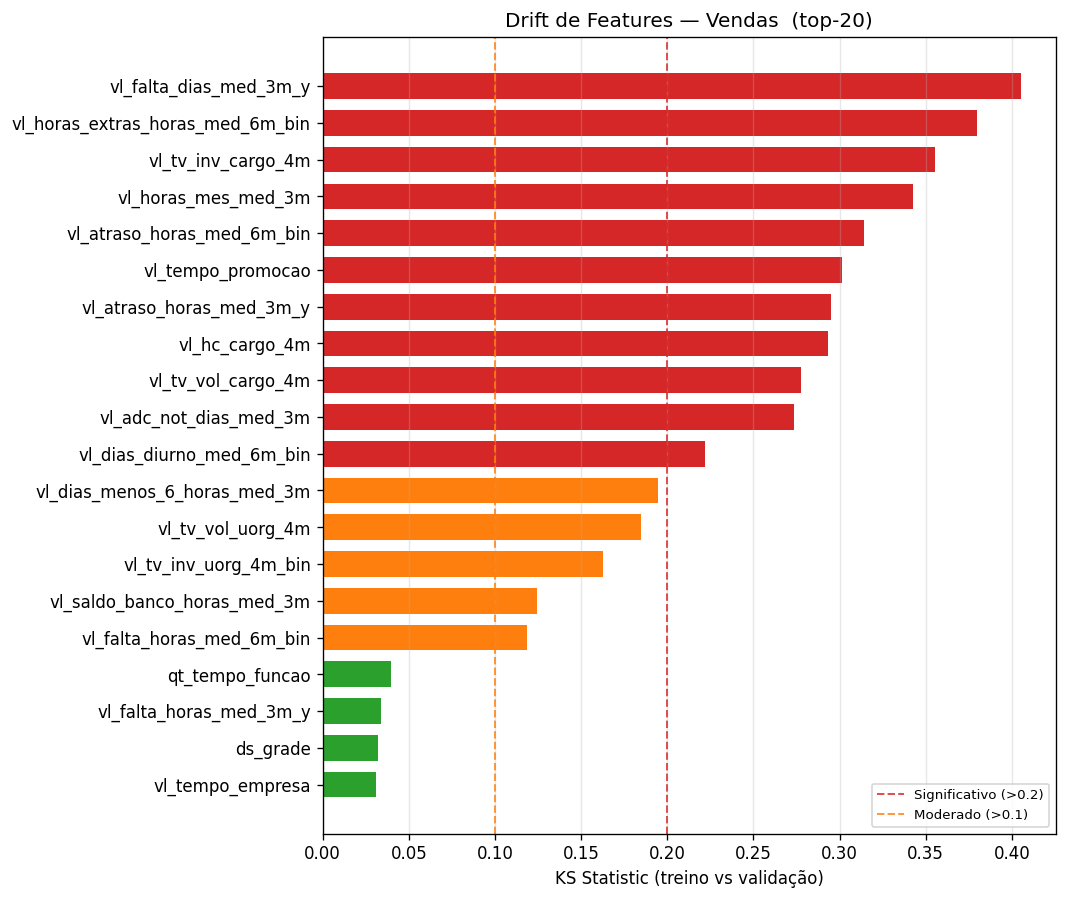


▶ Transporte
  50 features  |  significativo: 17  moderado: 9  estável: 24

                                   Feature       KS    p-val       JS           Nível
  ----------------------------------------------------------------------------------
                  vl_atraso_horas_med_3m_x   0.6161   0.0000   0.1621   significativo
                    vl_falta_dias_med_3m_x   0.5927   0.0000   0.2110   significativo
                    vl_falta_dias_med_3m_y   0.5348   0.0000   0.1648   significativo
                        vl_tv_vol_cargo_4m   0.4904   0.0000   0.2273   significativo
                         vl_tempo_promocao   0.4691   0.0000   0.2125   significativo
              vl_atraso_horas_med_3m_y_bin   0.4643   0.0000   0.1550   significativo
              vl_horas_extras_horas_med_3m   0.4565   0.0000   0.1357   significativo
                vl_atraso_horas_med_6m_bin   0.4513   0.0000   0.1585   significativo
               vl_atraso_dias_med_3m_y_bin   0.3403   0.0000   0

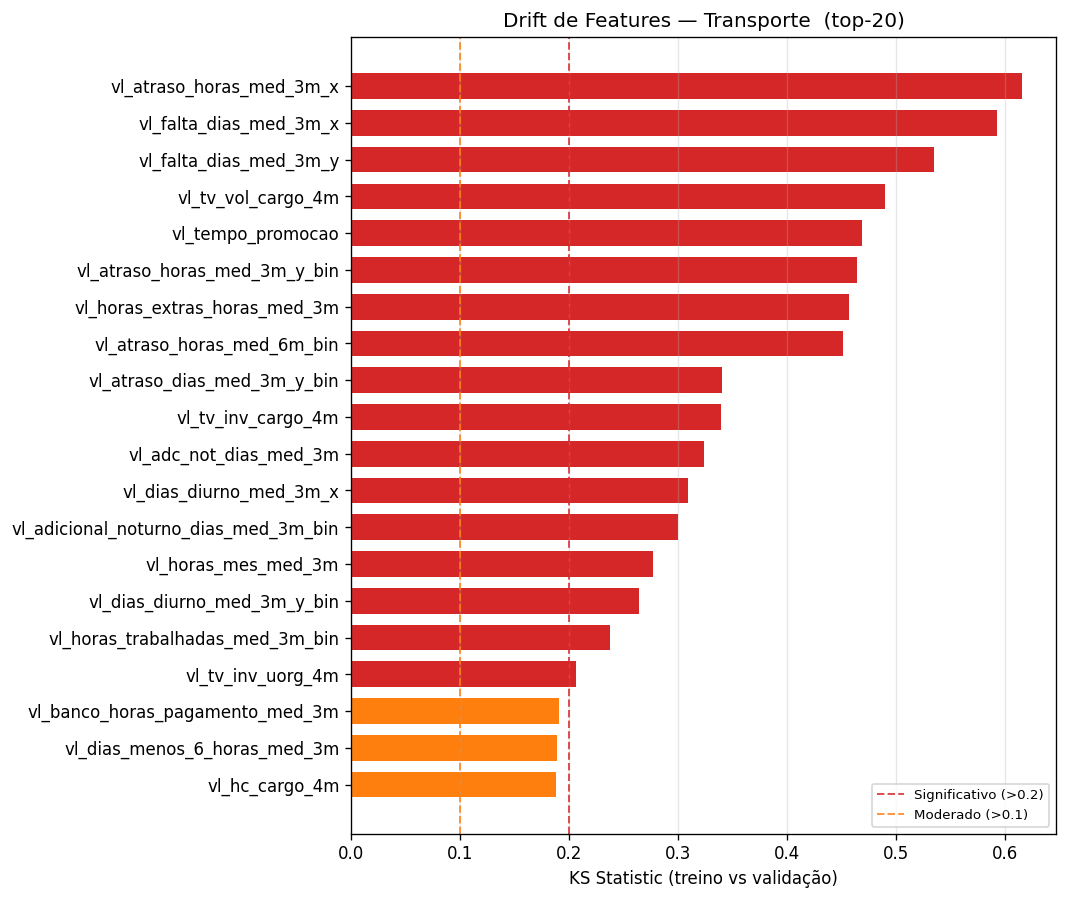


▶ Fábrica
  54 features  |  significativo: 18  moderado: 11  estável: 25

                                   Feature       KS    p-val       JS           Nível
  ----------------------------------------------------------------------------------
  vl_horas_extras_extraordinarias_horas_med_3m   0.6262   0.0000   0.2247   significativo
                    vl_falta_dias_med_3m_x   0.6013   0.0000   0.2256   significativo
                    vl_falta_dias_med_3m_y   0.5206   0.0000   0.1630   significativo
                  vl_atraso_horas_med_3m_x   0.4852   0.0000   0.1284   significativo
              vl_horas_extras_horas_med_3m   0.4650   0.0000   0.1432   significativo
                  vl_falta_dias_med_6m_bin   0.3920   0.0000   0.1013   significativo
                vl_atraso_horas_med_6m_bin   0.3835   0.0000   0.0971   significativo
                  vl_atraso_horas_med_3m_y   0.3727   0.0000   0.0907   significativo
                         vl_tempo_promocao   0.3639   0.0000  

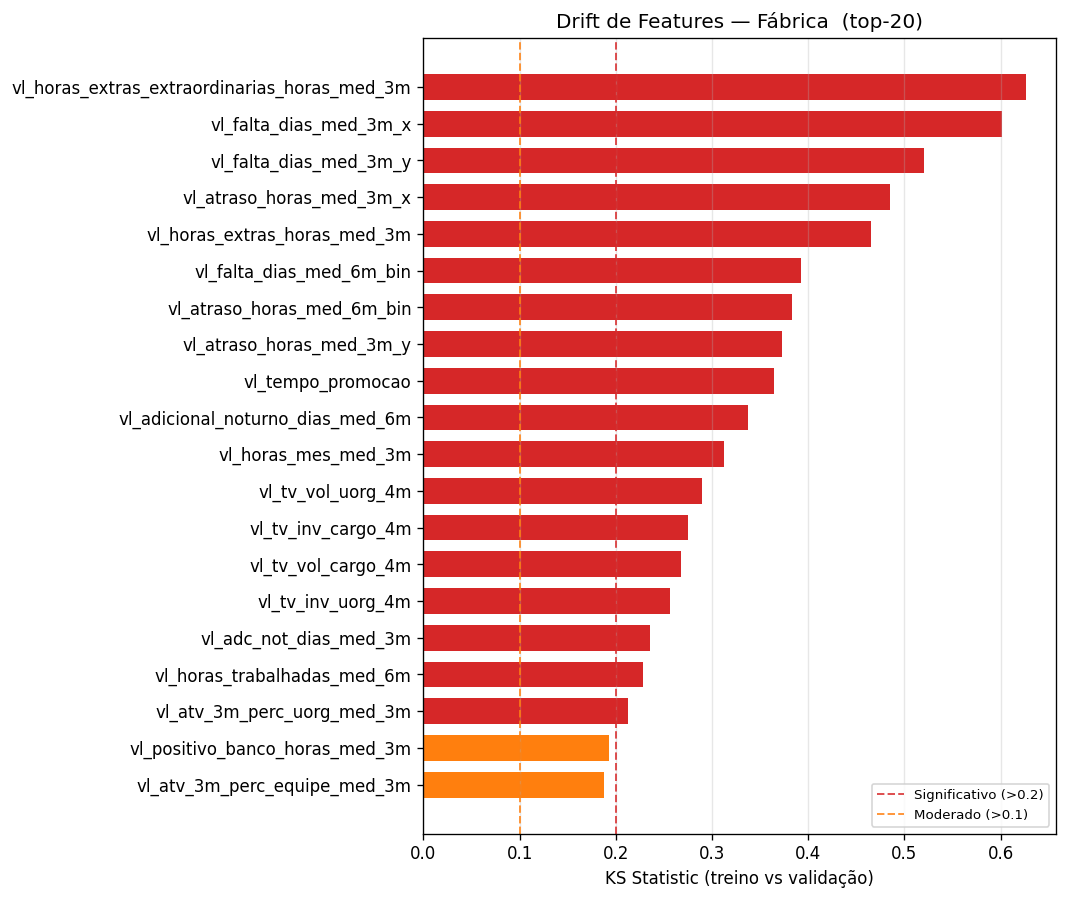


RESUMO CONSOLIDADO — Drift por grupo
nivel_drift  significativo  moderado  estável
grupo                                        
Fábrica                 18        11       25
Transporte              17         9       24
Vendas                  11         5        6


In [9]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ks_2samp
warnings.filterwarnings("ignore")

# ── Constantes (autocontido) ──────────────────────────────────
PROJECT_ROOT  = Path.cwd().parent
DATA_SPLITS   = PROJECT_ROOT / "data" / "processed" / "splits"
FS_DIR        = PROJECT_ROOT / "data" / "processed" / "feature_selection"
MODELS_DIR    = PROJECT_ROOT / "models"
GRUPOS        = ["Vendas", "Transporte", "Fábrica"]
DRIFT_KS_HIGH = 0.20
DRIFT_KS_MOD  = 0.10


def _js_divergence(a: np.ndarray, b: np.ndarray, n_bins: int = 20) -> float:
    """Jensen-Shannon divergence entre dois arrays via histograma compartilhado."""
    combined = np.concatenate([a, b])
    lo = float(np.nanpercentile(combined, 1))
    hi = float(np.nanpercentile(combined, 99))
    if lo >= hi:
        return 0.0
    bins = np.linspace(lo, hi, n_bins + 1)
    p = np.histogram(a, bins=bins, density=True)[0].astype(float) + 1e-10
    q = np.histogram(b, bins=bins, density=True)[0].astype(float) + 1e-10
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)
    js = 0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m)))
    return float(np.clip(js, 0.0, 1.0))


print("=" * 65)
print("DRIFT TREINO → VALIDAÇÃO  (KS test + JS divergence por feature)")
print("=" * 65)

all_drift_records = []

for GRUPO in GRUPOS:
    print(f"\n▶ {GRUPO}")

    grupo_splits = DATA_SPLITS / GRUPO
    grupo_fs_dir = FS_DIR      / GRUPO

    # Usa selected_features.json como fonte canônica (consistente com train.parquet)
    FEATURES = json.loads(
        (grupo_fs_dir / "selected_features.json").read_text(encoding="utf-8")
    )["selected_features"]

    df_train = pd.read_parquet(grupo_splits / "train.parquet")[FEATURES]
    df_val   = pd.read_parquet(grupo_splits / "val.parquet")[FEATURES]

    drift_records = []
    for feat in FEATURES:
        a = df_train[feat].dropna().values.astype(float)
        b = df_val[feat].dropna().values.astype(float)
        if len(a) < 5 or len(b) < 5:
            continue
        ks_stat, ks_pval = ks_2samp(a, b)
        js               = _js_divergence(a, b)
        nivel = ("significativo" if ks_stat > DRIFT_KS_HIGH
                 else "moderado"      if ks_stat > DRIFT_KS_MOD
                 else "estável")
        drift_records.append({
            "feature"    : feat,
            "ks_stat"    : round(float(ks_stat), 4),
            "ks_pval"    : round(float(ks_pval), 4),
            "js_div"     : round(js, 4),
            "nivel_drift": nivel,
            "grupo"      : GRUPO,
        })

    df_drift = pd.DataFrame(drift_records).sort_values("ks_stat", ascending=False)

    n_sig = (df_drift["nivel_drift"] == "significativo").sum()
    n_mod = (df_drift["nivel_drift"] == "moderado").sum()
    n_est = (df_drift["nivel_drift"] == "estável").sum()
    print(f"  {len(df_drift)} features  |  significativo: {n_sig}  moderado: {n_mod}  estável: {n_est}")

    print(f"\n  {'Feature':>40}  {'KS':>7}  {'p-val':>7}  {'JS':>7}  {'Nível':>14}")
    print("  " + "-" * 82)
    for _, row in df_drift.head(10).iterrows():
        print(f"  {row['feature']:>40}  {row['ks_stat']:>7.4f}  {row['ks_pval']:>7.4f}"
              f"  {row['js_div']:>7.4f}  {row['nivel_drift']:>14}")

    # ── Plot KS por feature (top-20) ─────────────────────────
    top20   = df_drift.head(20).iloc[::-1]
    palette = {"significativo": "#d62728", "moderado": "#ff7f0e", "estável": "#2ca02c"}
    colors  = [palette[n] for n in top20["nivel_drift"]]

    fig, ax = plt.subplots(figsize=(9, max(4, len(top20) * 0.38)))
    ax.barh(top20["feature"], top20["ks_stat"], color=colors, height=0.7)
    ax.axvline(DRIFT_KS_HIGH, color="#d62728", linestyle="--", linewidth=1.2,
               alpha=0.8, label=f"Significativo (>{DRIFT_KS_HIGH})")
    ax.axvline(DRIFT_KS_MOD,  color="#ff7f0e", linestyle="--", linewidth=1.2,
               alpha=0.8, label=f"Moderado (>{DRIFT_KS_MOD})")
    ax.set_xlabel("KS Statistic (treino vs validação)")
    ax.set_title(f"Drift de Features — {GRUPO}  (top-20)")
    ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    drift_path = PROJECT_ROOT / "reports" / "figures" / GRUPO / "drift_train_val.png"
    drift_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(drift_path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    all_drift_records.extend(drift_records)

# ── Resumo consolidado ────────────────────────────────────────
df_all = pd.DataFrame(all_drift_records)
pivot  = df_all.groupby(["grupo", "nivel_drift"]).size().unstack(fill_value=0)
for col in ["significativo", "moderado", "estável"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["significativo", "moderado", "estável"]]

print(f"\n{'='*65}")
print("RESUMO CONSOLIDADO — Drift por grupo")
print(pivot.to_string())
